In [1]:
import struct
import numpy as np

from pathlib import Path
from micrograd.tensor.engine import Tensor
from micrograd.tensor.nn import Sequential, Linear, ReLU, CrossEntropyLossWithLogits

In [2]:
project_dir = Path.cwd().parents[1]
data_dir = project_dir / "data/mnist"

In [3]:
# Load Images
def load_mnist_images(path):
    with open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images


def load_mnist_labels(path):
    with open(path, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


X_train = load_mnist_images(data_dir / "train-images.idx3-ubyte")
y_train = load_mnist_labels(data_dir / "train-labels.idx1-ubyte")

X_test = load_mnist_images(data_dir / "t10k-images.idx3-ubyte")
y_test = load_mnist_labels(data_dir / "t10k-labels.idx1-ubyte")


X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
# Normalize piXel values to [0, 1] and reshape them to (60000, 784)

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(X_train.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

X_train.shape, X_test.shape

((60000, 784), (10000, 784))

In [5]:
def accuracy(logits: Tensor, targets: np.ndarray) -> float:
    preds = logits.data.argmax(axis=1)   # (N,)
    return (preds == targets).mean()

In [6]:
model = Sequential(
    Linear(784, 128),
    ReLU(),
    Linear(128, 10),
)

criterion = CrossEntropyLossWithLogits()

In [7]:
# Training Loop
epochs = 10
batch_size = 32
lr = 0.1
N = X_train.shape[0]

for epoch in range(epochs):
    perm = np.random.permutation(N)
    running_loss = 0.0
    n_batches = 0

    for i in range(0, N, batch_size):
        idx = perm[i: i + batch_size]
        xb = Tensor(X_train[idx])
        yb = y_train[idx]

        # Forward
        logits = model(xb)
        loss = criterion(logits, yb)

        # Backward
        model.zero_grad()
        loss.backward()

        # SDG 
        for p in model.parameters():
            p.data -= lr * p.grad
        
        running_loss += float(loss.data)
        n_batches += 1
    
    test_logits = model(Tensor(X_test))
    acc = accuracy(test_logits, y_test)
    print(f"epoch: {epoch+1} | loss {running_loss/n_batches} | test acc {acc:.4f}" )


epoch: 1 | loss 0.29688986967404685 | test acc 0.9512
epoch: 2 | loss 0.1436172200858593 | test acc 0.9633
epoch: 3 | loss 0.10513564658761025 | test acc 0.9711
epoch: 4 | loss 0.08304525934855143 | test acc 0.9727
epoch: 5 | loss 0.06822149097720782 | test acc 0.9750
epoch: 6 | loss 0.05649633400440216 | test acc 0.9759
epoch: 7 | loss 0.04936965486605962 | test acc 0.9775
epoch: 8 | loss 0.04167454046408335 | test acc 0.9772
epoch: 9 | loss 0.03657904061675072 | test acc 0.9777
epoch: 10 | loss 0.03139869389533997 | test acc 0.9787


In [8]:
def predict(model, X: np.ndarray) -> np.ndarray:
    """X: (N, 784) numpy array. Returns (N,) predicted class indices."""
    logits = model(Tensor(X))
    return logits.data.argmax(axis=1)

In [9]:
import matplotlib.pyplot as plt


def show_predictions(model, X, y, n=16, cols=8, only_wrong=False, seed=None):
    """
    Plot n MNIST samples with predicted / true labels.
    Green title = correct, red = wrong.
    """
    rng = np.random.default_rng(seed)

    if only_wrong:
        preds_all = predict(model, X)
        pool = np.where(preds_all != y)[0]
        if len(pool) == 0:
            print("No misclassifications")
            return
        idx = rng.choice(pool, size=min(n, len(pool)), replace=False)
    else:
        idx = rng.choice(len(X), size=n, replace=False)

    preds = predict(model, X[idx])

    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.6))
    for ax, i, p in zip(axes.ravel(), idx, preds):
        ax.imshow(X[i].reshape(28, 28), cmap="gray")
        correct = (p == y[i])
        ax.set_title(f"pred {p} | true {y[i]}",
                     color=("green" if correct else "red"),
                     fontsize=8)
        ax.axis("off")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

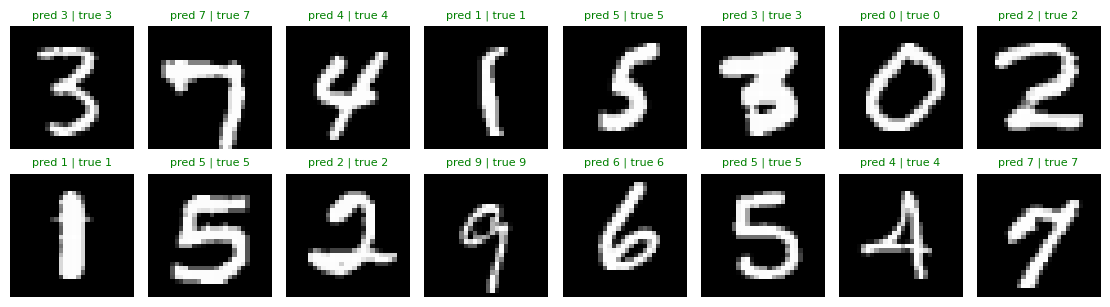

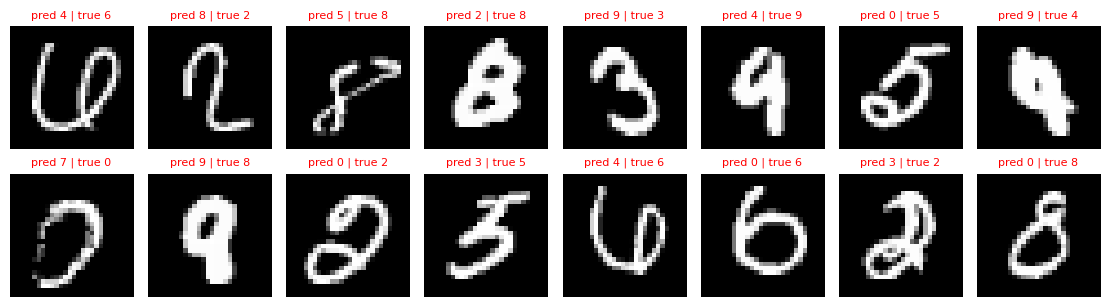

In [10]:
# Random sample of test predictions
show_predictions(model, X_test, y_test, n=16, seed=0)

# Misclassified only
show_predictions(model, X_test, y_test, n=16, only_wrong=True, seed=0)